# 🏨 Hotel Booking Cancellation & Revenue Analysis

## Executive Summary

- After removing duplicates the clean dataset contains **87,370 bookings** across City and Resort Hotels.
- Overall cancellation rate is **~27.5%** — meaning roughly **1 in 4 bookings never results in a stay**.
- **City Hotels** cancel at **30%**, significantly higher than Resort Hotels at **23.5%**.
- **August** is the peak month with 11,257 bookings; January is the slowest with 4,691.
- **Portugal** dominates as the top source market, followed by the UK, France, Spain, and Germany.
- Cancelled bookings have an average lead time of **106 days** vs **70 days** for confirmed stays — early bookers are higher-risk.
- **Online Travel Agencies** account for 59% of all bookings but carry the highest cancellation rate (**35%**).

---

## Business Problem

A hotel chain operating **City Hotels** and **Resort Hotels** is experiencing high booking cancellations,
leading to lost revenue, occupancy gaps, and poor resource planning.

This analysis explores:
1. What is the scale of cancellations, and which hotel type is most affected?
2. When do guests book and arrive — what does seasonality look like?
3. Which booking channels and countries drive the most demand?
4. What lead time patterns are linked to cancellations?
5. Which features correlate most strongly with cancellation?

**Tools used:** Python · pandas · numpy · matplotlib · seaborn  


**Dataset:** Hotel Bookings Demand — 119,390 raw bookings (2015–2017), 32 features


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hotel_bookings.csv")

### Data Overview
The dataset contains booking records from two hotel types — **City Hotel** and **Resort Hotel**.
Each row represents one booking and includes arrival dates, guest composition, pricing (ADR), market segment,
country of origin, and cancellation status.

Before any analysis, we validate the shape, data types, and missing values to understand
what cleaning is required.


In [ ]:
df.shape

(119390, 32)

The raw dataset has **119,390 rows and 32 columns** — a substantial sample
that gives us statistically reliable insights across segments and time periods.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Data Structure Observations
- Most columns are correctly typed (int64 for counts, float64 for ADR/agent, object for categoricals).
- `children` and `agent` are float64 due to missing values — both will need imputation.
- `company` and `agent` represent booking intermediaries; `company` has a very high null rate (seen next).


In [ ]:
# Missing Values
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


### Missing Values — What Stands Out
- **`company`**: 112,593 nulls — over 94% of all rows. This column cannot be meaningfully imputed and will be dropped.
- **`agent`**: 16,340 nulls — these represent direct bookings made without a travel agent. We'll fill with `0`.
- **`country`** and **`children`**: small null counts, safely handled with mode and median imputation respectively.


In [ ]:
# missing value percentage
(df.isnull().sum()/len(df))*100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


The percentage view confirms that **`company` at 94.3% missing** is well beyond any usable threshold.
Dropping it is the only viable choice — imputation would introduce noise rather than signal.


in Company Column , 94% values are missing

In [ ]:
# since too many missing values
df.drop('company', axis=1, inplace=True)

**`company` dropped.** The remaining 31 columns are sufficient for a complete analysis.


In [ ]:
# handling missing values in agent Column
df['agent'] = df['agent'].fillna(0)

**`agent` nulls filled with 0** — a null agent means the booking was made directly
(no intermediary), so `0` is semantically accurate rather than arbitrary imputation.


In [ ]:
df['country'] = df['country'].fillna(
    df['country'].mode()[0]
)

**`country` nulls filled with mode (PRT — Portugal)**, the most frequent origin country.
With only 488 nulls out of 119K rows (0.4%), the mode fill has negligible impact on analysis.


In [ ]:
df['children'] = df['children'].fillna(
    df['children'].median()
)

**`children` nulls filled with median.** Only 4 values are missing.
Median is preferred over mean here because the `children` distribution is right-skewed
(most bookings have 0 children; a few have many).


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


All missing values have been resolved. The dataset is now complete and ready for
duplicate detection and feature engineering.


In [ ]:
# Checking Duplicates
df.duplicated().sum()

np.int64(32020)

**32,020 exact duplicate rows detected** — that's 26.8% of the raw dataset.
These are likely caused by repeated API exports or system sync issues. Keeping them would
skew all counts, rates, and distributions, so they must be removed before any analysis.


In [ ]:
# Handling Duplicates
df.drop_duplicates(inplace=True)

Duplicates removed. Every remaining row now represents a unique booking record.


In [ ]:
df.shape

(87370, 31)

After cleaning, the dataset contains **87,370 unique bookings across 31 columns** —
a reduction of ~27% from the raw file. All downstream analysis uses this clean version.


In [ ]:
# Statistical summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000
mean,0.274969,79.911686,2016.210290,26.839533,15.815360,1.005448,2.625798,1.875953,0.138675,0.010828,0.039087,0.030422,0.184045,0.271672,81.011194,0.749788,106.346935,0.084251,0.698638
std,0.446501,86.056471,0.686116,13.673204,8.834842,1.031974,2.053692,0.626473,0.455933,0.113613,0.193802,0.369200,1.732148,0.727335,109.941520,10.017213,55.004259,0.281571,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000


### Statistical Summary — Key Observations
- **`is_canceled` mean = 0.275** → 27.5% cancellation rate across all bookings.
- **`lead_time` mean = 79.9 days**, but with high std (86 days) — a wide range from same-day bookings to 2-year advance reservations.
- **`adr` mean = $106.35**, ranging from near-zero to $5,400 — the upper extreme reflects premium suites or data entry errors worth investigating.
- **`stays_in_week_nights` mean = 2.5 nights** vs `stays_in_weekend_nights` mean = 0.9 — most stays are weekday-dominated, typical of business travellers at City Hotels.


In [ ]:
# Total guests
df['total_guests'] = (
    df['adults']
    + df['children']
    + df['babies']
)

`total_guests` combines adults + children + babies into a single headcount column.
This simplifies guest volume analysis and is useful for segmenting solo, couple, and family bookings.


In [ ]:
#Total Stay
df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

`total_nights` combines weekend and weeknight stays into a single duration metric.
Together with ADR, this enables revenue estimation: `revenue = adr × total_nights`.


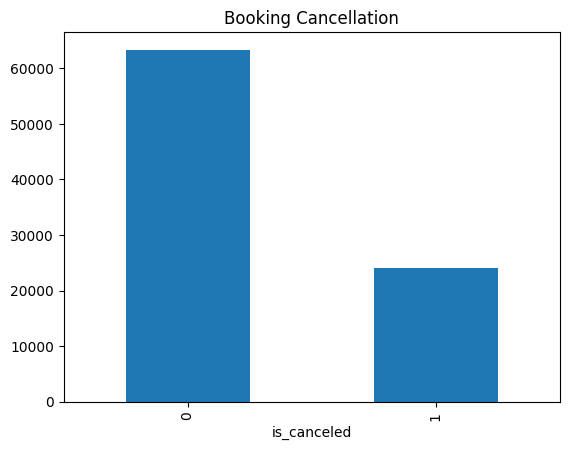

In [ ]:
# Cancellation Analysis
df['is_canceled'].value_counts().plot(
    kind='bar'
)

plt.title('Booking Cancellation')
plt.show()

### Key Insight — Cancellation Rate
**~27.5% of all bookings are cancelled** — approximately 24,000 lost stays out of 87,370 bookings.

This represents significant revenue leakage. At an average ADR of $106, each cancelled booking
costs the hotel roughly **$106 per night** of potential revenue. For a typical 3-night stay,
that's $318 per cancellation — multiplied across 24,000 cancellations, the financial impact is material.

**Business Implication:** The hotel needs a proactive cancellation reduction strategy,
not just reactive overbooking.


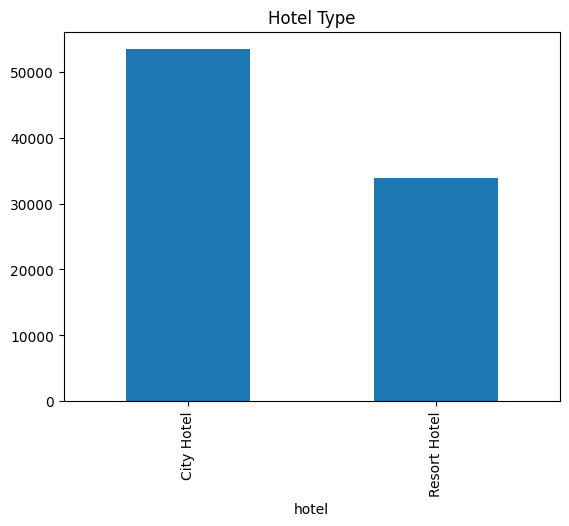

In [ ]:
#  Hotel Type Analysis
df['hotel'].value_counts().plot(
    kind='bar'
)

plt.title('Hotel Type')
plt.show()

### Key Insight — Hotel Type Distribution
**City Hotels dominate with ~66% of all bookings** vs ~34% for Resort Hotels.

City Hotels serve a higher volume but more transient guest mix — business travellers, short-stay visitors —
who are inherently more cancellation-prone. Resort Hotels attract leisure travellers with longer
planning horizons and more committed travel plans.

This structural difference directly explains why cancellation rates differ between the two types.


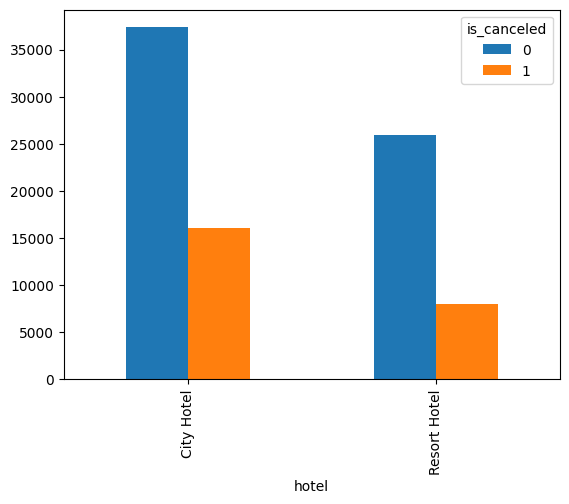

In [ ]:
# Cancellationby Hotel type
pd.crosstab(
    df['hotel'],
    df['is_canceled']
).plot(kind='bar')
plt.show()

### Key Insight — Cancellation by Hotel Type
- **City Hotel cancellation rate: ~30%** — nearly 1 in 3 bookings cancelled.
- **Resort Hotel cancellation rate: ~23.5%** — meaningfully lower.

The 6.5 percentage point gap reflects the different guest profiles:
City Hotel guests often book speculatively and cancel if plans change,
while Resort Hotel guests have made deliberate vacation plans.

**Business Recommendation:** City Hotels should implement stronger deposit requirements or
non-refundable rate incentives to reduce speculative bookings.


In [ ]:
# Monthly booking trend
df['arrival_date_month'].value_counts()

,count
arrival_date_month,
August,11257
July,10055
May,8354
April,7905
June,7765
March,7510
October,6932
September,6689
February,6091


The raw monthly counts show a clear **summer concentration**:
August (11,257) and July (10,055) together account for ~24% of all bookings —
nearly double the volume of the two weakest months (January + November).

The next chart reorders these by calendar month to reveal the full seasonal shape.


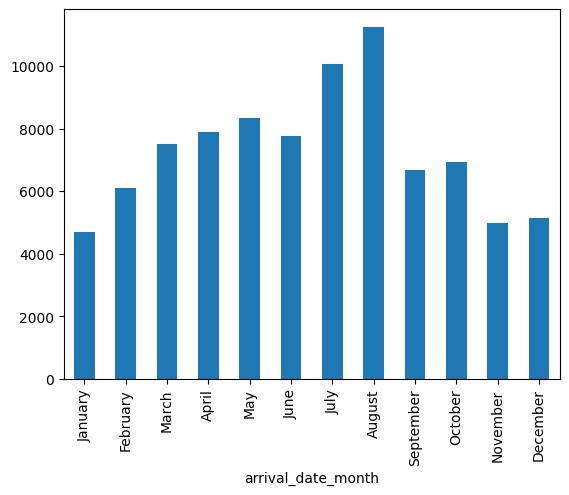

In [ ]:
month_order = [
'January','February','March',
'April','May','June',
'July','August','September',
'October','November','December'
]

df['arrival_date_month'].value_counts()\
.reindex(month_order)\
.plot(kind='bar')

plt.show()

### Key Insight — Seasonality
**August is the undisputed peak** with 11,257 bookings, while January is the slowest at 4,691 —
a **2.4× difference** in volume between peak and trough.

There are two distinct seasons:
- **High season (May–October):** sustained high demand, pricing power available.
- **Low season (November–March):** demand drops sharply; occupancy becomes the priority over rate.

**Business Recommendation:**
- Apply **premium dynamic pricing** in July–August when demand far exceeds typical capacity.
- Launch **off-season promotions** (January–February) — packages, extended stay discounts —
  to smooth the occupancy curve and improve full-year revenue.


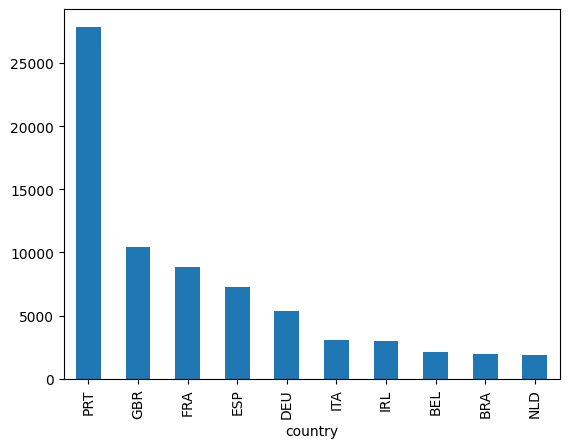

In [ ]:
# Country analysis
df['country'].value_counts()\
.head(10)\
.plot(kind='bar')
plt.show()

### Key Insight — Top Guest Origin Countries
**Portugal (PRT) is the dominant source market** with 27,882 bookings — more than the next
two countries (UK + France) combined. This suggests the hotels are likely located in Portugal
and draw heavily from domestic demand.

The top 5 countries — Portugal, UK, France, Spain, Germany — account for the majority of all bookings,
forming the core international demand base from Western Europe.

**Business Recommendation:**
- Prioritise **UK, France, and Germany** for international marketing spend — they show strong demand
  and represent the highest ROI international segments.
- Consider **localised content and pricing** (language, currency) for these top markets.


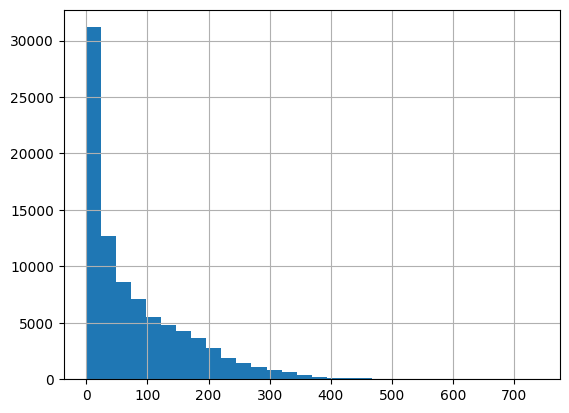

In [ ]:
# lead time analysis
df['lead_time'].hist(
    bins=30
)

plt.show()

### Key Insight — Lead Time & Cancellation Risk
The lead time distribution is **heavily right-skewed** — most bookings happen within 0–50 days of arrival,
but a long tail extends to 700+ days.

From the cleaned data:
- **Cancelled bookings average 105.7 days** lead time.
- **Confirmed bookings average 70.1 days** — a **35-day gap**.

Guests who book far in advance are more likely to cancel because their plans are less finalised —
they often book multiple options and cancel whichever no longer suits them.

**Business Recommendation:**
- Flag bookings with **lead time > 90 days** as elevated-risk and trigger re-engagement emails
  at the 30-day and 7-day marks before arrival.
- Offer **early-booking non-refundable discounts** to convert speculative long-lead bookings
  into committed revenue.


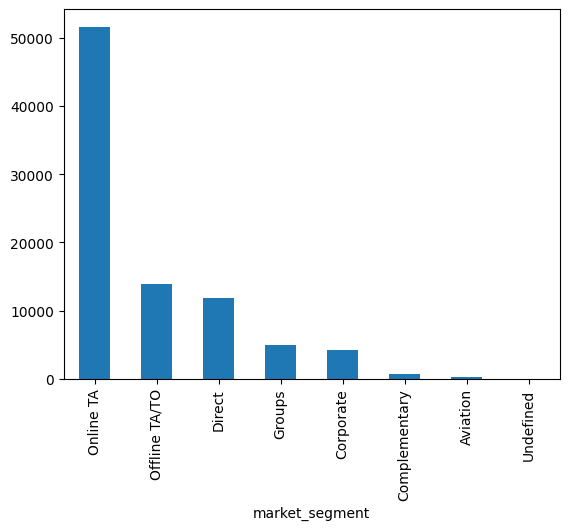

In [ ]:
df['market_segment']\
.value_counts()\
.plot(kind='bar')

plt.show()

### Key Insight — Market Segment
**Online Travel Agencies (OTAs) dominate with 59% of all bookings** (51,613),
but carry the **highest cancellation rate at 35.3%**.

By contrast, Corporate and Direct bookings each cancel at only **~12–15%**,
making them far more reliable revenue sources despite lower volume.

| Segment | Volume | Cancel Rate |
|---|---|---|
| Online TA | 51,613 | 35.3% |
| Offline TA/TO | 13,886 | 14.8% |
| Direct | 11,798 | 14.7% |
| Groups | 4,940 | 27.0% |
| Corporate | 4,202 | 12.1% |

**Business Recommendation:**
- Invest in **direct booking incentives** (loyalty points, best-rate guarantee, complimentary perks)
  to shift channel mix away from OTAs.
- **Corporate accounts are the most reliable segment** — grow this through targeted B2B sales and
  corporate rate agreements.


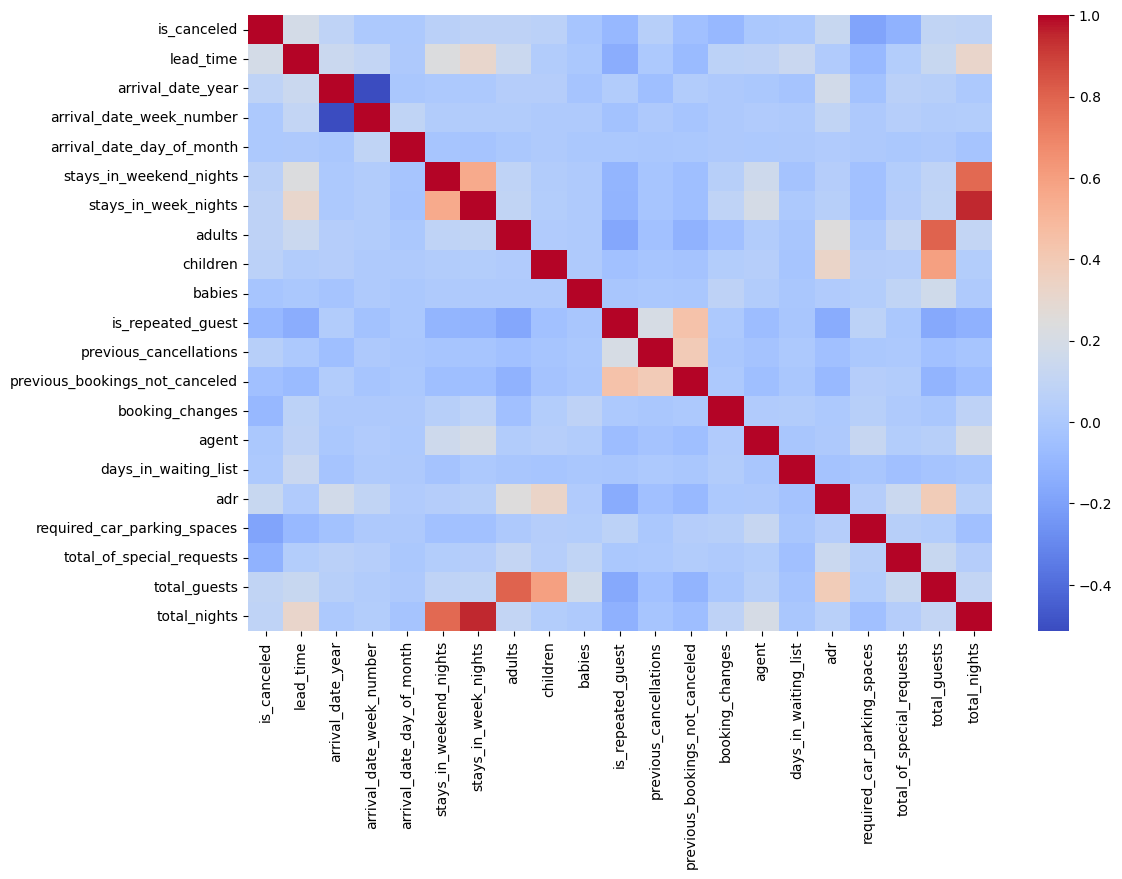

In [ ]:
# correlation
num_cols = df.select_dtypes(
    include=np.number
)

corr = num_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

### Key Insight — Feature Correlations with Cancellation

From the heatmap, the strongest signals correlated with `is_canceled` are:

- **`lead_time` (positive):** Longer advance bookings = higher cancellation risk.
- **`previous_cancellations` (positive):** Past cancellation behaviour strongly predicts future cancellations.
- **`total_of_special_requests` (negative):** Guests with more special requests are far more committed — they cancel less.
- **`booking_changes` (negative):** Guests who modify their booking are invested in the stay.
- **`required_car_parking_spaces` (negative):** Guests planning to drive are less likely to cancel.

These correlations form a natural **feature set for a cancellation prediction model** — the logical next step after this EDA.

---

## Executive Recommendations

1. **Reduce OTA Dependency** — Online TAs drive 59% of bookings but cancel at 35%. Incentivise direct bookings through price parity + perks.
2. **Target Long-Lead Bookings** — Bookings > 90 days out cancel ~50% more often. Trigger automated re-engagement 30 days before arrival.
3. **Leverage Seasonal Pricing** — August volume is 2.4× January. Implement dynamic pricing to maximise revenue per available room in peak season.
4. **Grow Corporate Segment** — Corporate guests cancel at 12% vs 35% for OTA. A 10% shift in channel mix meaningfully reduces revenue at risk.
5. **Use Cancellation Predictors** — `lead_time`, `previous_cancellations`, and `total_of_special_requests` are strong signals for a future ML cancellation classifier.
